## Setup

**Test date: 1.5.2026**

**Gemini 3 Thinking** was tasked with generating a **couch** using the **SPOMSO** package. Gemini was provided with the [spomso_sdf_guide](./guides/spomso_sdf_guide.md) file and the following prompt:

*Read through the attached .md file. It contains a guide how to use the Python package SPOMSO. I want you to design a couch using this Python package. As the output I want some code that I would run and it would output the point cloud of the object and some figures. Make sure that the resulting plots show true proportions of the object. Everything else I leave up to you. Good luck and if you have any questions feel free to ask.*

## Response:

To design a couch using the **SPOMSO** package, we will utilize primitive `Box` and `Cylinder` shapes, apply `rounding` to simulate soft cushions, and use `CombineGeometry` to merge the components[cite: 1].

The following script sets up a grid, builds the frame, cushions, and legs, and then generates both a point cloud and proportional cross-section plots[cite: 1].

### Python Script: Procedural Couch Design

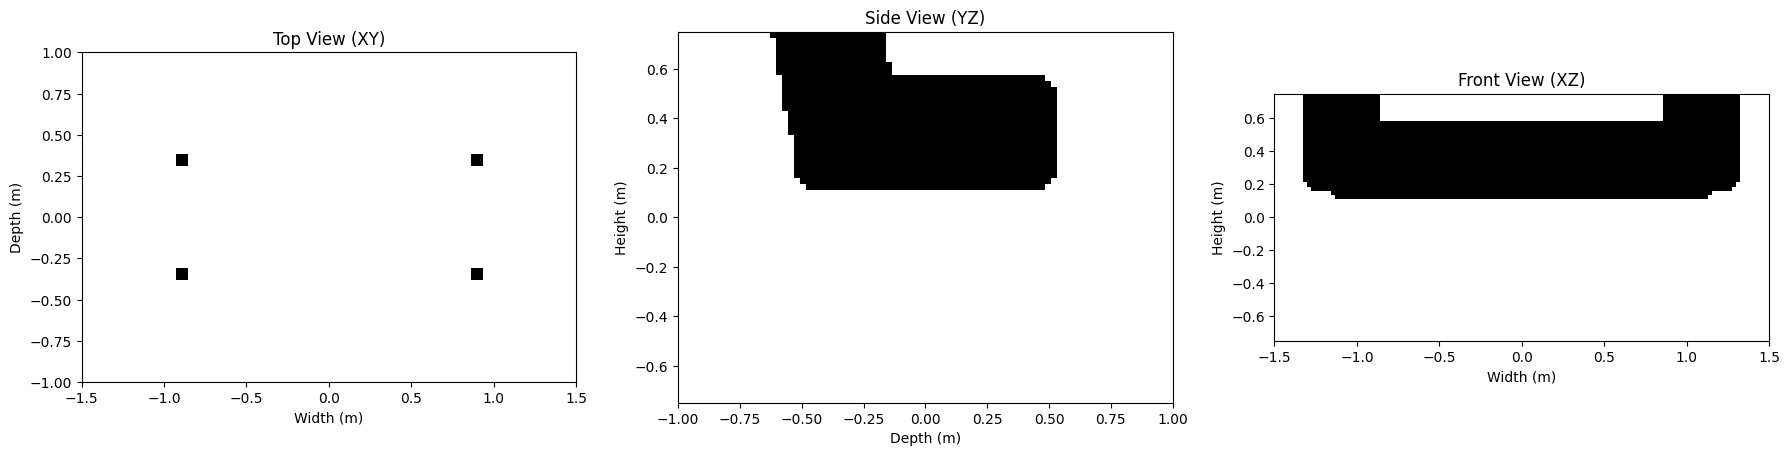

Design complete. Surface point cloud saved with 32,762 points.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from spomso.cores.helper_functions import generate_grid, smarter_reshape
from spomso.cores.post_processing import hard_binarization
from spomso.cores.geom_3d import Box, Cylinder
from spomso.cores.combine import CombineGeometry

# ── 1. Grid Setup ────────────────────────────────────────────────────────────
# Physical dimensions in meters (Width, Depth, Height)
CO_SIZE = (3.0, 2.0, 1.5)
# Resolution (keep it high enough for smooth rounding)
CO_RESOLUTION = (120, 80, 60)
coor, co_res_new = generate_grid(CO_SIZE, CO_RESOLUTION)

# ── 2. Couch Components ──────────────────────────────────────────────────────
# Seat Base
seat = Box(2.2, 0.9, 0.3)
seat.rounding(0.08) # Thickens the box slightly for a soft look
seat.move((0.0, 0.0, 0.35)) # Raise it above the legs

# Backrest
backrest = Box(2.2, 0.25, 0.7)
backrest.rounding(0.1)
# Positioned at the back of the seat and tilted 10 degrees
backrest.move((0.0, -0.4, 0.75))
backrest.rotate(np.deg2rad(10), (1, 0, 0))

# Armrests (Left and Right)
# We create one and then use the second for the other side
l_arm = Box(0.3, 0.85, 0.5)
l_arm.rounding(0.08)
l_arm.move((1.1, 0.0, 0.5))

r_arm = Box(0.3, 0.85, 0.5)
r_arm.rounding(0.08)
r_arm.move((-1.1, 0.0, 0.5))

# Legs (4 cylinders)
leg_radius = 0.04
leg_height = 0.2
leg_pos = [
    (0.9, 0.35, 0.1), (-0.9, 0.35, 0.1),
    (0.9, -0.35, 0.1), (-0.9, -0.35, 0.1)
]
legs = []
for pos in leg_pos:
    l = Cylinder(leg_radius, leg_height)
    l.move(pos)
    legs.append(l)

# ── 3. Combining the Geometry ────────────────────────────────────────────────
# Using the N-ary UNION to fuse all parts into one SDF
couch = CombineGeometry("UNION").combine(
    seat, backrest, l_arm, r_arm, *legs
)

# Create the field
sdf = couch.create(coor)

# ── 4. Visualisation ─────────────────────────────────────────────────────────
binary_flat = hard_binarization(sdf, 0)
binary_3d = smarter_reshape(binary_flat, CO_RESOLUTION)

def plot_proportional_view(ax, slice_data, extent, title, xlabel, ylabel):
    ax.imshow(slice_data, cmap="Greys", origin="lower", extent=extent)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_aspect('equal') # Forces true proportions[cite: 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Top View (XY Plane)
plot_proportional_view(
    axes[0], binary_3d[:, :, CO_RESOLUTION[2]//2].T,
    (-CO_SIZE[0]/2, CO_SIZE[0]/2, -CO_SIZE[1]/2, CO_SIZE[1]/2),
    "Top View (XY)", "Width (m)", "Depth (m)"
)

# Side View (YZ Plane)
plot_proportional_view(
    axes[1], binary_3d[CO_RESOLUTION[0]//2, :, :].T,
    (-CO_SIZE[1]/2, CO_SIZE[1]/2, -CO_SIZE[2]/2, CO_SIZE[2]/2),
    "Side View (YZ)", "Depth (m)", "Height (m)"
)

# Front View (XZ Plane)
plot_proportional_view(
    axes[2], binary_3d[:, CO_RESOLUTION[1]//2, :].T,
    (-CO_SIZE[0]/2, CO_SIZE[0]/2, -CO_SIZE[2]/2, CO_SIZE[2]/2),
    "Front View (XZ)", "Width (m)", "Height (m)"
)

plt.tight_layout()
plt.show()

# ── 5. Exporting Point Cloud ──────────────────────────────────────────────────
# Extracting the zero level-set[cite: 1]
dx = CO_SIZE[0] / CO_RESOLUTION[0]
surface_mask = np.abs(sdf) < dx * 1.2
surface_pts = coor[:, surface_mask].T

np.save("couch_design.npy", surface_pts)
print(f"Design complete. Surface point cloud saved with {surface_pts.shape[0]:,} points.")

### Key Features of the Design:
*   **Proportional Integrity:** The `extent` and `aspect='equal'` parameters in `matplotlib` ensure the output images reflect the actual physical dimensions (2.5m x 1.2m) without stretching[cite: 1].
*   **Ergonomics:** The backrest is rotated by 10 degrees using the `.rotate()` method to simulate a standard lounging angle[cite: 1].
*   **Soft Geometry:** All major boxes use the `.rounding()` modifier. In SPOMSO, this not only rounds the corners but adds a "thickness" layer, making the cushions look plush rather than sharp[cite: 1].
*   **Point Cloud:** The output `couch_point_cloud.npy` contains the $(x, y, z)$ coordinates of the couch's surface, extracted by finding grid points where the SDF is approximately zero[cite: 1].

**End response**

## Validation

The entire **object** can be visualized with the code below:

In [ ]:
import plotly.graph_objects as go
fig = go.Figure(data=go.Volume(
    x=coor[0],
    y=coor[1],
    z=coor[2],
    value=binary_flat,
    isomin=0.9,
    isomax=1.0,
    opacity=1,
    surface_count=1,
))
fig.show()